In [633]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import requests
import io
from sklearn.model_selection import train_test_split

In [634]:
historical_url = 'https://en.wikipedia.org/w/index.php?title=NIFTY_50&oldid=1217916746#Constituents' # 28 March 2024
# historical_url = 'https://en.wikipedia.org/w/index.php?title=NIFTY_50&oldid=1284465884#Constituents' # 28 March 2025

tables = pd.read_html(
    historical_url,
    match='Symbol', 
    storage_options={'User-Agent': 'Mozilla/5.0'}
)

nifty50_df = tables[0]
tickers = nifty50_df['Symbol'].astype(str) + '.NS'

print("Historical Constituents List:")
print(tickers.tolist())

Historical Constituents List:
['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BHARTIARTL.NS', 'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS', 'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS', 'INFY.NS', 'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'LTIM.NS', 'M&M.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TATAMOTORS.NS', 'TATASTEEL.NS', 'TCS.NS', 'TATACONSUM.NS', 'TECHM.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS']


In [635]:
tickers = nifty50_df['Symbol'].astype('str') + '.NS'
tickers_list = tickers.to_list()

# 2 years:
raw_train_data = yf.download(tickers_list, start='2020-04-01', end='2024-03-31', interval='1wk')
raw_test_data = yf.download(tickers_list, start='2024-04-01', interval='1wk')

# 1 year:
# raw_train_data = yf.download(tickers_list, start='2021-04-01', end='2025-03-31', interval='1wk')
# raw_test_data = yf.download(tickers_list, start='2025-04-01', interval='1wk')

[*******               14%                       ]  7 of 50 completed$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  50 of 50 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  50 of 50 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


In [636]:
nifty50_index = yf.download('^NSEI', start='2024-04-01', interval='1wk')
# nifty50_index = yf.download('^NSEI', start='2025-04-01', interval='1wk')

[*********************100%***********************]  1 of 1 completed


In [637]:
close_train_prices = raw_train_data['Close']
close_test_prices = raw_test_data['Close']
benchmark = nifty50_index['Close']

In [638]:
display(close_train_prices.isna().sum())
display(close_test_prices.isna().sum())
display(benchmark.isna().sum())

Ticker
ADANIENT.NS        0
ADANIPORTS.NS      0
APOLLOHOSP.NS      0
ASIANPAINT.NS      0
AXISBANK.NS        0
BAJAJ-AUTO.NS      0
BAJAJFINSV.NS      0
BAJFINANCE.NS      0
BHARTIARTL.NS      0
BPCL.NS            0
BRITANNIA.NS       0
CIPLA.NS           0
COALINDIA.NS       0
DIVISLAB.NS        0
DRREDDY.NS         0
EICHERMOT.NS       0
GRASIM.NS          0
HCLTECH.NS         0
HDFCBANK.NS        0
HDFCLIFE.NS        0
HEROMOTOCO.NS      0
HINDALCO.NS        0
HINDUNILVR.NS      0
ICICIBANK.NS       0
INDUSINDBK.NS      0
INFY.NS            0
ITC.NS             0
JSWSTEEL.NS        0
KOTAKBANK.NS       0
LT.NS              0
LTIM.NS            0
M&M.NS             0
MARUTI.NS          0
NESTLEIND.NS       0
NTPC.NS            0
ONGC.NS            0
POWERGRID.NS       0
RELIANCE.NS        0
SBILIFE.NS         0
SBIN.NS            0
SHRIRAMFIN.NS      0
SUNPHARMA.NS       0
TATACONSUM.NS      0
TATAMOTORS.NS    209
TATASTEEL.NS       0
TCS.NS             0
TECHM.NS           0
TITAN.

Ticker
ADANIENT.NS        0
ADANIPORTS.NS      0
APOLLOHOSP.NS      0
ASIANPAINT.NS      0
AXISBANK.NS        0
BAJAJ-AUTO.NS      0
BAJAJFINSV.NS      0
BAJFINANCE.NS      0
BHARTIARTL.NS      0
BPCL.NS            0
BRITANNIA.NS       0
CIPLA.NS           0
COALINDIA.NS       0
DIVISLAB.NS        0
DRREDDY.NS         0
EICHERMOT.NS       0
GRASIM.NS          0
HCLTECH.NS         0
HDFCBANK.NS        0
HDFCLIFE.NS        0
HEROMOTOCO.NS      0
HINDALCO.NS        0
HINDUNILVR.NS      0
ICICIBANK.NS       0
INDUSINDBK.NS      0
INFY.NS            0
ITC.NS             0
JSWSTEEL.NS        0
KOTAKBANK.NS       0
LT.NS              0
LTIM.NS            0
M&M.NS             0
MARUTI.NS          0
NESTLEIND.NS       0
NTPC.NS            0
ONGC.NS            0
POWERGRID.NS       0
RELIANCE.NS        0
SBILIFE.NS         0
SBIN.NS            0
SHRIRAMFIN.NS      0
SUNPHARMA.NS       0
TATACONSUM.NS      0
TATAMOTORS.NS    107
TATASTEEL.NS       0
TCS.NS             0
TECHM.NS           0
TITAN.

Ticker
^NSEI    0
dtype: int64

In [639]:
common_cols = close_train_prices.columns.intersection(close_test_prices.columns)

valid_cols = [
    c for c in common_cols
    if close_train_prices[c].notna().all() and close_test_prices[c].notna().all()
]

close_train_prices = close_train_prices.loc[:, valid_cols]
close_test_prices = close_test_prices.loc[:, valid_cols]

In [640]:
display(close_train_prices.columns.value_counts().sum())
display(close_test_prices.columns.value_counts().sum())

np.int64(49)

np.int64(49)

In [641]:
log_returns = np.log(close_train_prices/close_train_prices.shift(1)).dropna()

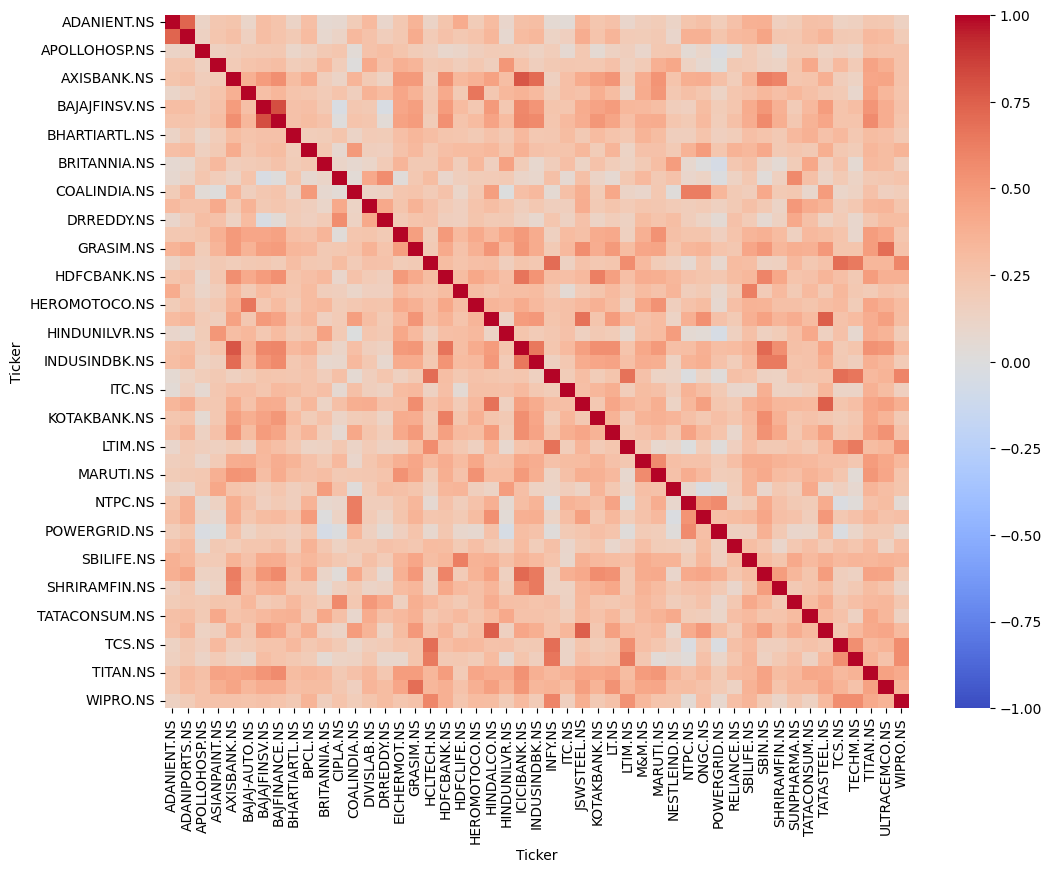

In [642]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [643]:
scaled_log_returns = StandardScaler().fit_transform(log_returns)

pca = PCA(n_components=10)
pca.fit(scaled_log_returns)

PCA(n_components=10)

In [644]:
display(pca.explained_variance_)
display(pca.explained_variance_ratio_)

array([15.07277507,  3.78936701,  2.93097077,  2.37615547,  1.74919763,
        1.60279611,  1.57918033,  1.24508734,  1.20744006,  1.09956284])

array([0.30612877, 0.07696222, 0.05952815, 0.04825983, 0.03552629,
       0.03255286, 0.03207323, 0.02528778, 0.02452316, 0.02233217])

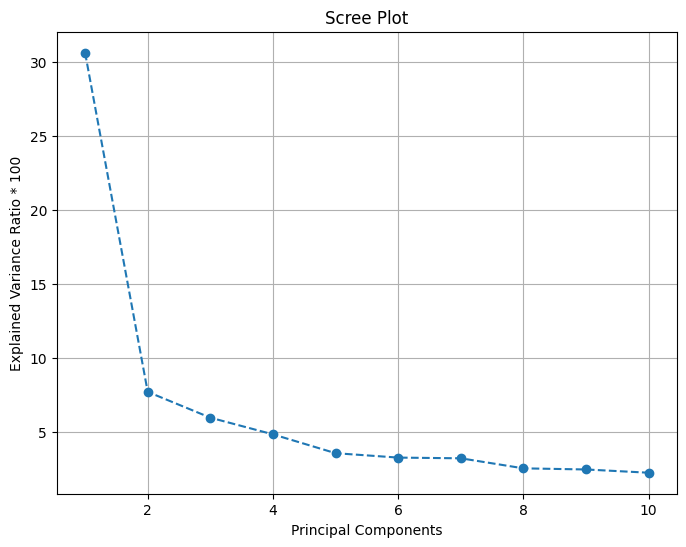

In [645]:
plt.figure(figsize=(8, 6))
plt.plot(range(1,11), pca.explained_variance_ratio_*100, marker='o', linestyle='--')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio * 100')
plt.title('Scree Plot')
plt.grid()
plt.show()

In [646]:
industry_map = (nifty50_df[['Symbol', 'Sector[18]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[18]']) # 2 years
# industry_map = (nifty50_df[['Symbol', 'Sector[15]']].drop_duplicates('Symbol').set_index('Symbol')['Sector[15]']) # 1 year

In [647]:
pc1_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[0] * 100
})

pc1_df['Industry'] = pc1_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc1_sorted = pc1_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc1_sorted.head(10))
display(pc1_sorted.tail(10))

,Ticker,Weight,Industry
23,ICICIBANK.NS,19.380494,Banking
46,TITAN.NS,18.545570,Consumer Durables
16,GRASIM.NS,18.424002,Materials
4,AXISBANK.NS,18.172662,Banking
39,SBIN.NS,17.893473,Banking
7,BAJFINANCE.NS,17.691229,Financial Services
18,HDFCBANK.NS,17.525357,Banking
47,ULTRACEMCO.NS,17.509091,Materials
21,HINDALCO.NS,17.379048,Metals
27,JSWSTEEL.NS,17.024815,Metals


,Ticker,Weight,Industry
45,TECHM.NS,11.546317,Information Technology
22,HINDUNILVR.NS,11.421534,Consumer Goods
0,ADANIENT.NS,11.233713,Diversified
37,RELIANCE.NS,10.976391,Diversified
33,NESTLEIND.NS,10.475984,Consumer Goods
10,BRITANNIA.NS,9.884024,Consumer Goods
14,DRREDDY.NS,9.626842,Pharmaceuticals
36,POWERGRID.NS,8.725153,Energy - Power
11,CIPLA.NS,8.459256,Pharmaceuticals
2,APOLLOHOSP.NS,8.023525,Healthcare


In [648]:
pc2_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[1] * 100
})

pc2_df['Industry'] = pc2_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc2_sorted = pc2_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc2_sorted.head(10))
display(pc2_sorted.tail(10))

,Ticker,Weight,Industry
25,INFY.NS,30.632082,Information Technology
44,TCS.NS,28.260129,Information Technology
17,HCLTECH.NS,27.778580,Information Technology
48,WIPRO.NS,23.004922,Information Technology
45,TECHM.NS,22.556054,Information Technology
30,LTIM.NS,22.290523,Information Technology
11,CIPLA.NS,21.513337,Pharmaceuticals
14,DRREDDY.NS,17.633850,Pharmaceuticals
3,ASIANPAINT.NS,14.117294,Consumer Durables
22,HINDUNILVR.NS,13.628523,Consumer Goods


,Ticker,Weight,Industry
29,LT.NS,-11.447531,Construction
40,SHRIRAMFIN.NS,-12.619501,Financial Services
23,ICICIBANK.NS,-13.824373,Banking
35,ONGC.NS,-14.144444,Energy - Oil & Gas
24,INDUSINDBK.NS,-17.130159,Banking
4,AXISBANK.NS,-17.285973,Banking
12,COALINDIA.NS,-19.570799,Energy - Coal
36,POWERGRID.NS,-20.207116,Energy - Power
39,SBIN.NS,-22.064182,Banking
34,NTPC.NS,-23.560818,Energy - Power


In [649]:
pc3_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[2] * 100
})

pc3_df['Industry'] = pc3_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc3_sorted = pc3_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc3_sorted.head(10))
display(pc3_sorted.tail(10))

,Ticker,Weight,Industry
45,TECHM.NS,30.266404,Information Technology
30,LTIM.NS,25.497039,Information Technology
35,ONGC.NS,21.614707,Energy - Oil & Gas
17,HCLTECH.NS,21.291803,Information Technology
25,INFY.NS,21.018231,Information Technology
12,COALINDIA.NS,20.514613,Energy - Coal
43,TATASTEEL.NS,19.208645,Metals
21,HINDALCO.NS,17.599433,Metals
48,WIPRO.NS,17.199461,Information Technology
27,JSWSTEEL.NS,15.571649,Metals


,Ticker,Weight,Industry
20,HEROMOTOCO.NS,-10.721034,Automotive
28,KOTAKBANK.NS,-11.100698,Banking
42,TATACONSUM.NS,-16.433968,Consumer Goods
5,BAJAJ-AUTO.NS,-17.823010,Automotive
32,MARUTI.NS,-19.118953,Automotive
15,EICHERMOT.NS,-19.297731,Automotive
3,ASIANPAINT.NS,-20.211468,Consumer Durables
10,BRITANNIA.NS,-24.596093,Consumer Goods
33,NESTLEIND.NS,-28.721965,Consumer Goods
22,HINDUNILVR.NS,-29.601046,Consumer Goods


In [650]:
pc4_df = pd.DataFrame({
    'Ticker': log_returns.columns,
    'Weight': pca.components_[3] * 100
})

pc4_df['Industry'] = pc4_df['Ticker'].str.replace('.NS', '', regex=False).map(industry_map)

pc4_sorted = pc4_df.sort_values(by='Weight', ascending=False)

pd.set_option('display.max_rows', None)
display(pc4_sorted.head(10))
display(pc4_sorted.tail(10))

,Ticker,Weight,Industry
14,DRREDDY.NS,31.763262,Pharmaceuticals
11,CIPLA.NS,30.999996,Pharmaceuticals
13,DIVISLAB.NS,27.967571,Pharmaceuticals
41,SUNPHARMA.NS,25.443994,Pharmaceuticals
34,NTPC.NS,24.799691,Energy - Power
12,COALINDIA.NS,18.001894,Energy - Coal
35,ONGC.NS,15.935754,Energy - Oil & Gas
1,ADANIPORTS.NS,15.880090,Infrastructure
27,JSWSTEEL.NS,15.300322,Metals
0,ADANIENT.NS,13.076305,Diversified


,Ticker,Weight,Industry
44,TCS.NS,-14.505196,Information Technology
45,TECHM.NS,-14.577256,Information Technology
24,INDUSINDBK.NS,-14.918279,Banking
25,INFY.NS,-14.944140,Information Technology
30,LTIM.NS,-16.989648,Information Technology
28,KOTAKBANK.NS,-17.059462,Banking
23,ICICIBANK.NS,-18.426559,Banking
18,HDFCBANK.NS,-20.856390,Banking
7,BAJFINANCE.NS,-22.673804,Financial Services
6,BAJAJFINSV.NS,-24.061468,Financial Services


### Performance Measurement

In [651]:
# ==============================================================================
# 1. CORE MATH & PORTFOLIO SIMULATION ENGINES
# ==============================================================================
def extract_strategy_weights(pca_model, columns, pc_index, strategy_type='auto'):
    """Extracts and normalizes weights based on the chosen strategy."""
    raw_weights = pca_model.components_[pc_index]
    
    # Auto-detect strategy: PC1 is usually Long-Only, everything else is Long/Short
    if strategy_type == 'auto':
        strategy_type = 'long_only' if pc_index == 0 else 'long_short'
        
    if strategy_type == 'long_only':
        # Fix sign direction for PC1
        if np.sum(raw_weights) < 0:
            raw_weights = -raw_weights
        long_weights = np.maximum(0, raw_weights)
        return pd.Series(long_weights / np.sum(long_weights), index=columns), 'Long-Only'
        
    elif strategy_type == 'long_short':
        # Normalize Longs to +1.0 and Shorts to -1.0 (Dollar Neutral)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        return pd.Series(norm_longs + norm_shorts, index=columns), 'Long/Short (Market Neutral)'

def simulate_portfolio(price_data, weights, initial_capital, strategy_name):
    """Simulates the portfolio equity curve based on strategy type."""
    initial_prices = price_data.iloc[0]
    shares = (initial_capital * weights) / initial_prices
    
    if strategy_name == 'Long-Only':
        # Portfolio value is just the current value of the shares held
        return price_data.dot(shares)
    else:
        # Long/Short Portfolio: Initial Capital is margin. 
        # PnL = (Current Prices * Shares). Note: Shorts are negative shares, so dropping prices = profit.
        return initial_capital + price_data.dot(shares)

def align_benchmark(benchmark_data, initial_capital):
    """Normalizes the benchmark to start at the exact same capital as the portfolio."""
    if isinstance(benchmark_data, pd.DataFrame):
        benchmark_data = benchmark_data.iloc[:, 0]
    return (benchmark_data / benchmark_data.iloc[0]) * initial_capital

# ==============================================================================
# 2. INSTITUTIONAL METRICS ENGINE
# ==============================================================================
def calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr):
    df = pd.concat([port_val, bench_val], axis=1).dropna()
    df.columns = ['Portfolio', 'Benchmark']
    
    returns = df.pct_change().dropna()
    p_ret, b_ret = returns['Portfolio'], returns['Benchmark']
    
    # CAGR
    ann_p_ret = (df['Portfolio'].iloc[-1] / df['Portfolio'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    ann_b_ret = (df['Benchmark'].iloc[-1] / df['Benchmark'].iloc[0]) ** (periods_per_yr / len(returns)) - 1
    
    # Volatility
    ann_p_vol = p_ret.std() * np.sqrt(periods_per_yr)
    ann_b_vol = b_ret.std() * np.sqrt(periods_per_yr)
    
    # Sharpe
    p_sharpe = (ann_p_ret - rf_rate) / ann_p_vol
    b_sharpe = (ann_b_ret - rf_rate) / ann_b_vol
    
    # Sortino
    p_down_dev = np.sqrt(np.mean(np.where(p_ret < 0, p_ret**2, 0))) * np.sqrt(periods_per_yr)
    p_sortino = (ann_p_ret - rf_rate) / p_down_dev if p_down_dev > 0 else np.nan
    b_down_dev = np.sqrt(np.mean(np.where(b_ret < 0, b_ret**2, 0))) * np.sqrt(periods_per_yr)
    b_sortino = (ann_b_ret - rf_rate) / b_down_dev if b_down_dev > 0 else np.nan
    
    # Drawdowns
    p_dd = (df['Portfolio'] - df['Portfolio'].cummax()) / df['Portfolio'].cummax()
    b_dd = (df['Benchmark'] - df['Benchmark'].cummax()) / df['Benchmark'].cummax()
    
    # Beta & Alpha
    cov = np.cov(p_ret, b_ret)
    beta = cov[0, 1] / cov[1, 1]
    alpha = ann_p_ret - (rf_rate + beta * (ann_b_ret - rf_rate))
    
    # Calmar
    p_calmar = ann_p_ret / abs(p_dd.min())
    b_calmar = ann_b_ret / abs(b_dd.min())
    
    metrics = pd.DataFrame({
        'Portfolio': [f"{ann_p_ret*100:.2f}%", f"{ann_p_vol*100:.2f}%", f"{p_sharpe:.2f}", f"{p_sortino:.2f}", f"{p_dd.min()*100:.2f}%", f"{p_calmar:.2f}", f"{beta:.2f}", f"{alpha*100:.2f}%"],
        'Benchmark': [f"{ann_b_ret*100:.2f}%", f"{ann_b_vol*100:.2f}%", f"{b_sharpe:.2f}", f"{b_sortino:.2f}", f"{b_dd.min()*100:.2f}%", f"{b_calmar:.2f}", "1.00", "0.00%"]
    }, index=['Return (CAGR)', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Calmar Ratio', 'Beta', "Jensen's Alpha"])
    
    return metrics, p_dd, b_dd, p_ret, b_ret

# ==============================================================================
# 3. MASTER WRAPPER & PLOTTING DASHBOARD
# ==============================================================================
def evaluate_pc_strategy(pca_model, pc_index, price_data, benchmark_data, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52):
    """
    The Ultimate Master Function. Put in a PC index, get out the full institutional dashboard.
    """
    # 1. Build Portfolio
    weights, strat_name = extract_strategy_weights(pca_model, price_data.columns, pc_index, strategy)
    port_val = simulate_portfolio(price_data, weights, initial_capital, strat_name)
    bench_val = align_benchmark(benchmark_data, initial_capital)
    
    # 2. Get Metrics
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(port_val, bench_val, rf_rate, periods_per_yr)
    
    # 3. Print Results
    actual_pc = pc_index + 1
    print("\n" + "="*65)
    print(f" STRATEGY REPORT: Principal Component {actual_pc} [{strat_name}]")
    print("="*65)
    display(metrics_df)
    
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val.index, (port_val/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val.index, (bench_val/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()




 STRATEGY REPORT: Principal Component 1 [Long-Only]


,Portfolio,Benchmark
Return (CAGR),7.93%,2.85%
Volatility,14.39%,13.53%
Sharpe Ratio,0.13,-0.23
Sortino Ratio,0.20,-0.34
Max Drawdown,-16.63%,-15.49%
Calmar Ratio,0.48,0.18
Beta,1.03,1.00
Jensen's Alpha,5.17%,0.00%


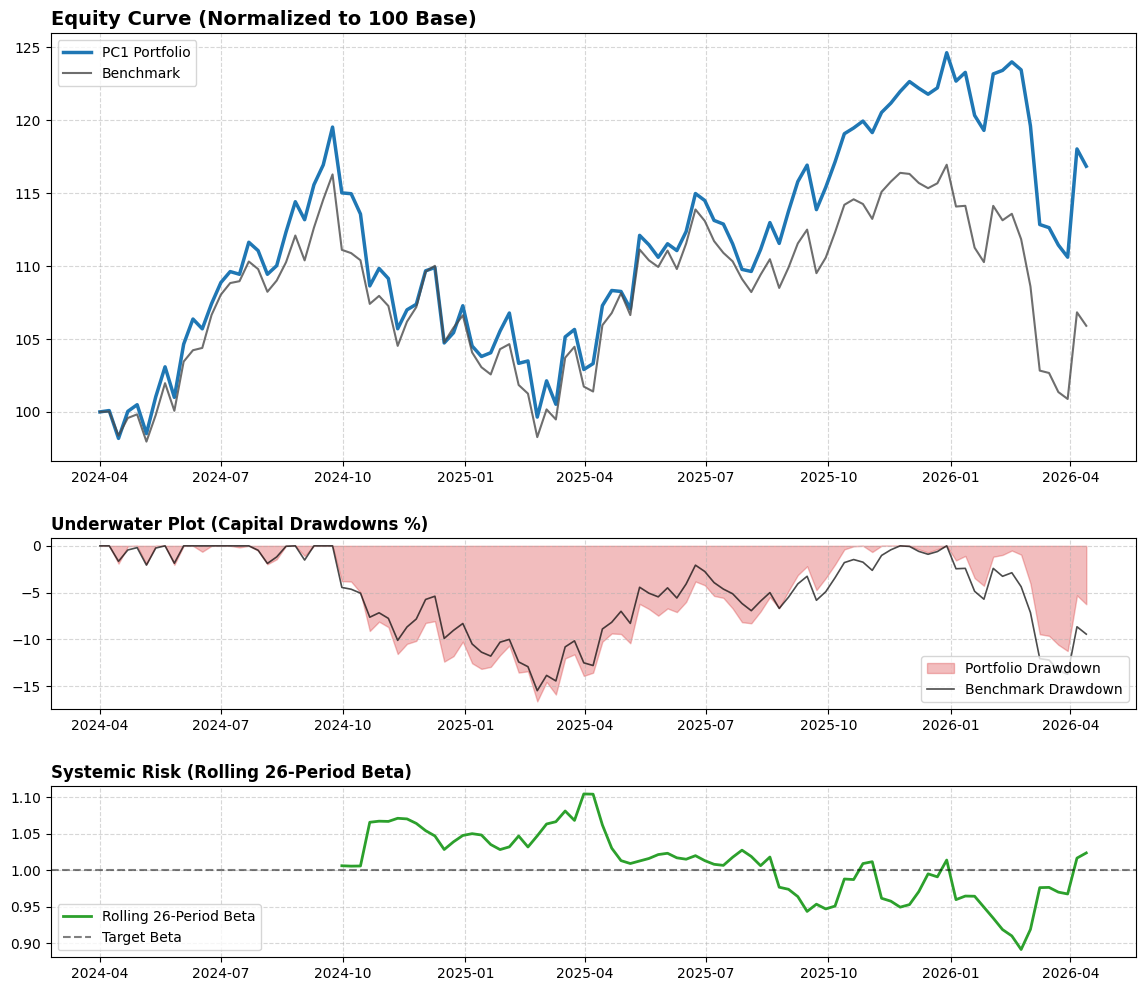

In [652]:
# Test PC1
evaluate_pc_strategy(pca_model=pca, pc_index=0, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=52)


 STRATEGY REPORT: Principal Component 2 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-9.50%,2.85%
Volatility,16.87%,13.53%
Sharpe Ratio,-0.92,-0.23
Sortino Ratio,-1.20,-0.34
Max Drawdown,-34.48%,-15.49%
Calmar Ratio,-0.28,0.18
Beta,-0.28,1.00
Jensen's Alpha,-16.37%,0.00%


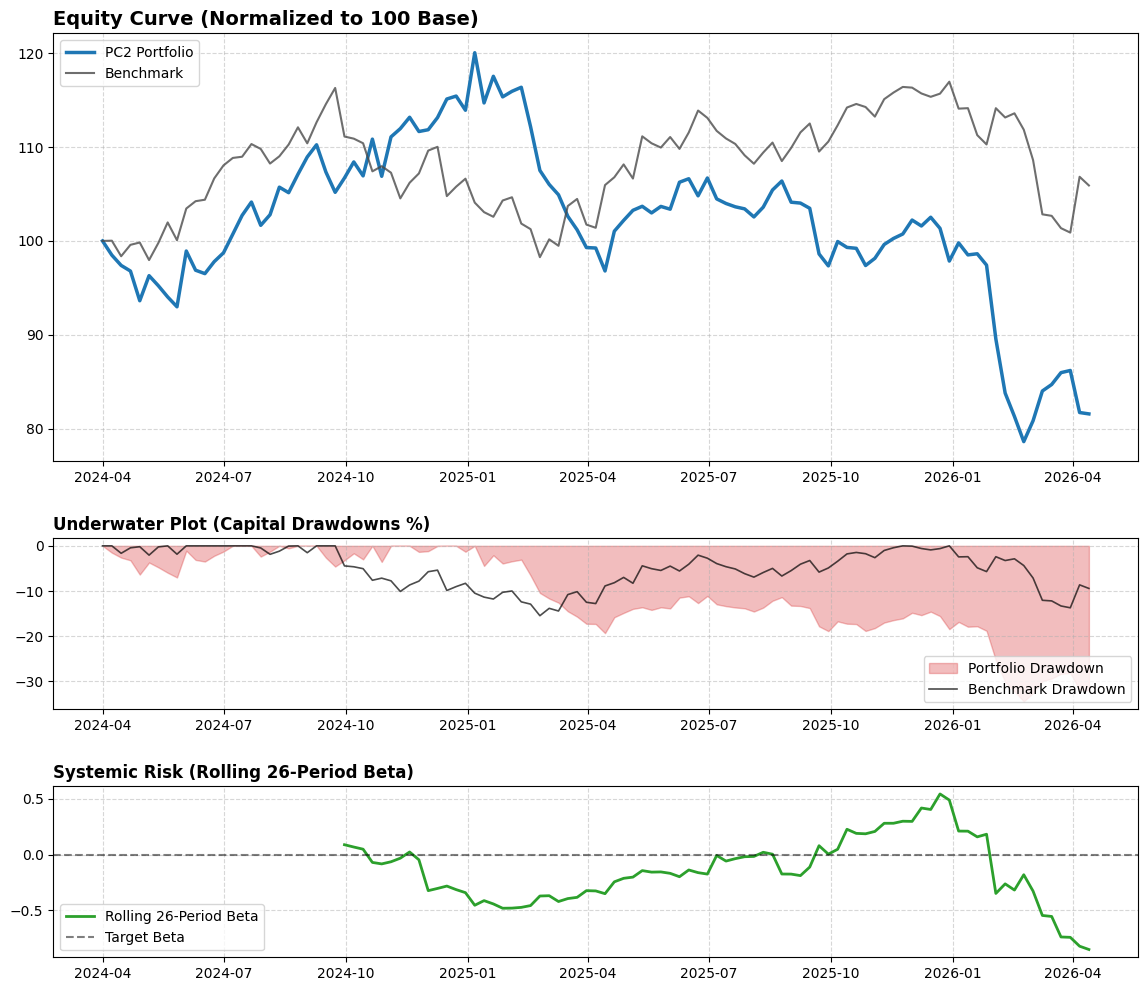

In [653]:
# Test PC2
evaluate_pc_strategy(pca_model=pca, pc_index=1, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=52)


 STRATEGY REPORT: Principal Component 3 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),-1.78%,2.85%
Volatility,16.75%,13.53%
Sharpe Ratio,-0.46,-0.23
Sortino Ratio,-0.63,-0.34
Max Drawdown,-25.28%,-15.49%
Calmar Ratio,-0.07,0.18
Beta,-0.06,1.00
Jensen's Alpha,-7.98%,0.00%


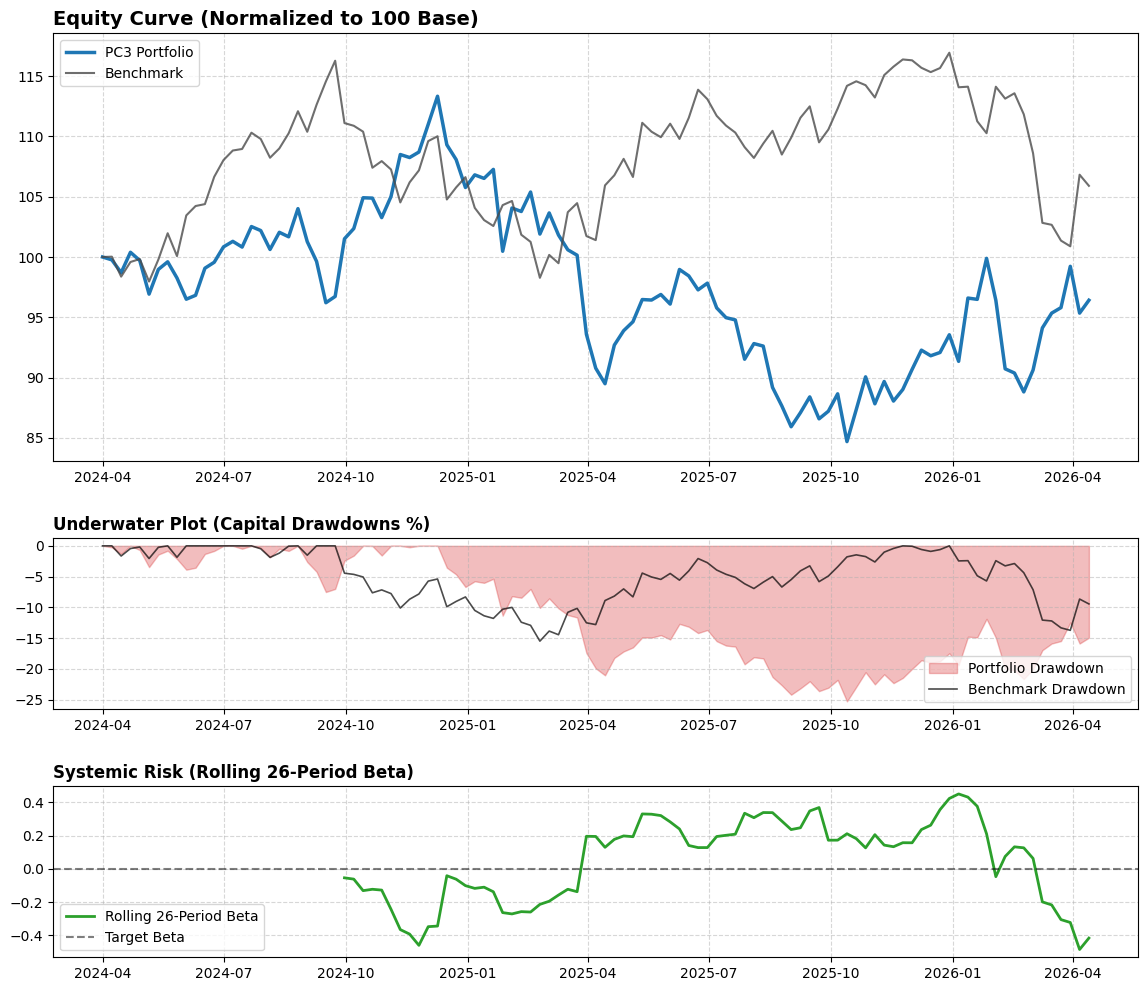

In [654]:
# Test PC3
evaluate_pc_strategy(pca_model=pca, pc_index=2, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=52)


 STRATEGY REPORT: Principal Component 4 [Long/Short (Market Neutral)]


,Portfolio,Benchmark
Return (CAGR),0.70%,2.85%
Volatility,13.57%,13.53%
Sharpe Ratio,-0.39,-0.23
Sortino Ratio,-0.60,-0.34
Max Drawdown,-17.73%,-15.49%
Calmar Ratio,0.04,0.18
Beta,-0.14,1.00
Jensen's Alpha,-5.76%,0.00%


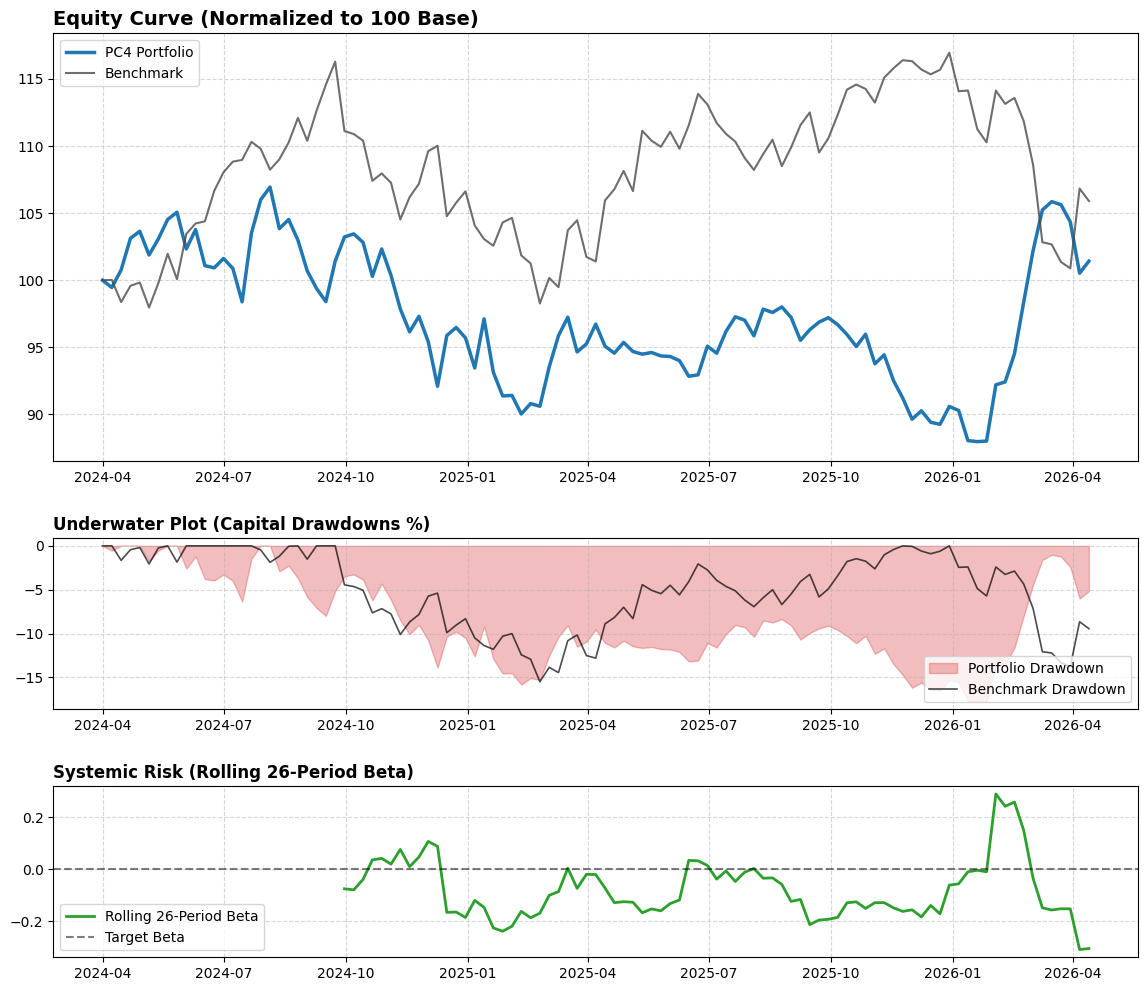

In [655]:
evaluate_pc_strategy(pca_model=pca, pc_index=3, price_data=close_test_prices, benchmark_data=benchmark, periods_per_yr=52)


 MULTI-FACTOR PORTFOLIO: PC2 + PC3 + PC4 (Equal Weighting)


,Portfolio,Benchmark
Return (CAGR),-3.42%,2.85%
Volatility,9.41%,13.53%
Sharpe Ratio,-1.00,-0.23
Sortino Ratio,-1.31,-0.34
Max Drawdown,-17.00%,-15.49%
Calmar Ratio,-0.20,0.18
Beta,-0.16,1.00
Jensen's Alpha,-9.94%,0.00%


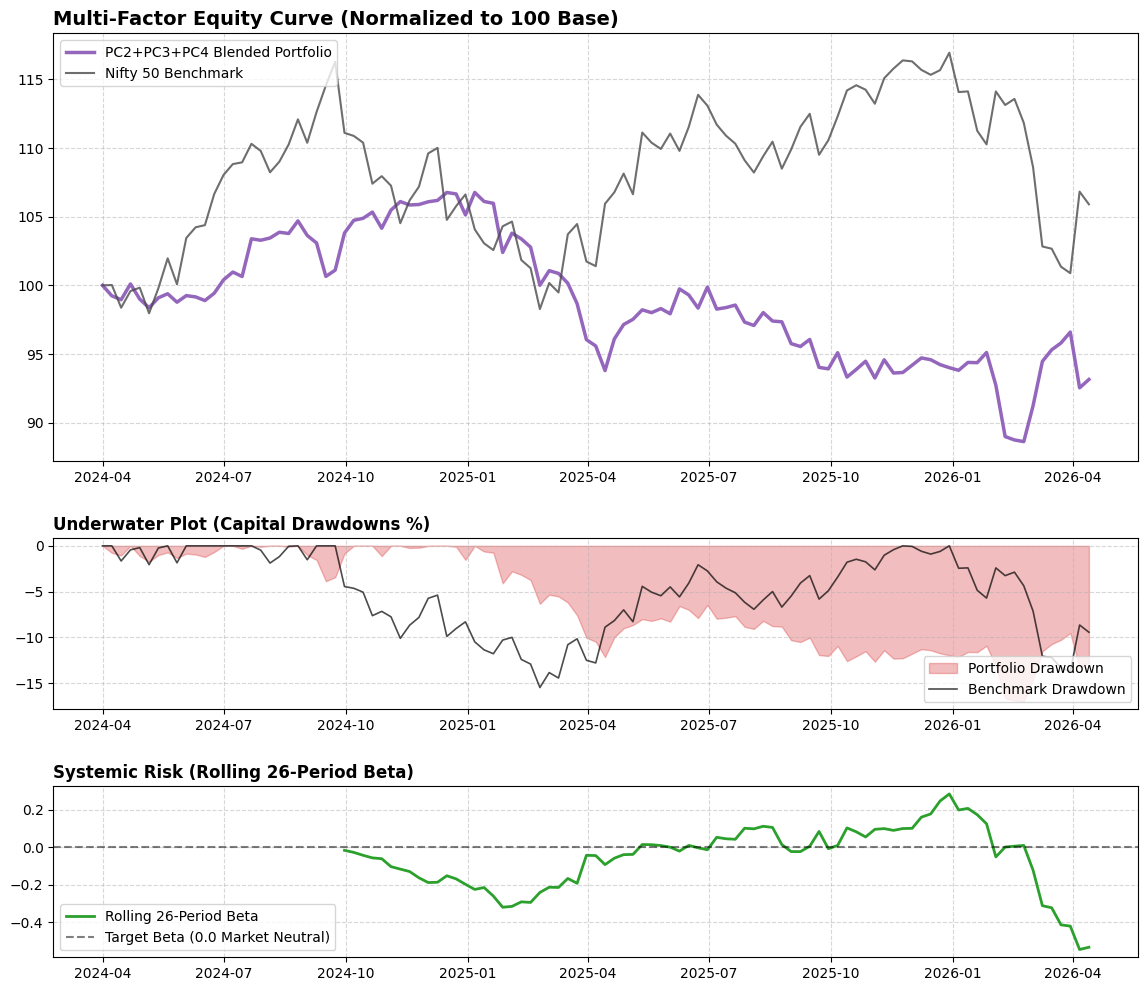

In [656]:
# ==============================================================================
# 1. MULTI-FACTOR WEIGHT GENERATOR
# ==============================================================================
def get_combined_multi_pc_weights(pca_model, columns, pc_indices, allocations):
    """
    Combines multiple Principal Components into a single weighted portfolio.
    Assumes all provided components are traded as Market-Neutral Long/Short.
    """
    # Start with a blank slate of 0.0 weights for all stocks
    combined_weights = pd.Series(0.0, index=columns)
    
    for pc_idx, alloc in zip(pc_indices, allocations):
        # Extract raw weights for this component
        raw_weights = pca_model.components_[pc_idx]
        
        # Normalize as Long/Short (+1.0 Longs, -1.0 Shorts)
        longs = np.maximum(0, raw_weights)
        shorts = np.minimum(0, raw_weights)
        
        norm_longs = longs / np.sum(longs) if np.sum(longs) > 0 else longs
        norm_shorts = shorts / abs(np.sum(shorts)) if np.sum(shorts) < 0 else shorts
        
        # This component's final normalized weights
        pc_weights = pd.Series(norm_longs + norm_shorts, index=columns)
        
        # Apply the allocation multiplier and add to the master portfolio
        combined_weights += (pc_weights * alloc)
        
    return combined_weights

# ==============================================================================
# 2. EXECUTION & DASHBOARD 
# ==============================================================================

# We want PC2 (Index 1), PC3 (Index 2), and PC4 (Index 3)
indices_to_combine = [1, 2, 3] 

# Equal weightage: 33.33% allocated to each component
allocations = [1/3, 1/3, 1/3]

# Generate the Master Blended Weights
master_weights = get_combined_multi_pc_weights(pca, close_test_prices.columns, indices_to_combine, allocations)

# Since PC2, 3, and 4 are all Market-Neutral spreads, the combined portfolio is also Long/Short
combined_port_val = simulate_portfolio(
    price_data=close_test_prices, 
    weights=master_weights, 
    initial_capital=100000, 
    strategy_name='Long/Short'
)
bench_val = align_benchmark(benchmark, initial_capital=100000)

# Calculate Institutional Metrics (Using 52 for Weekly data, change to 252 if using Daily)
metrics_df_combo, p_dd, b_dd, p_ret, b_ret = calculate_metrics(
    port_val=combined_port_val, 
    bench_val=bench_val, 
    rf_rate=0.06, 
    periods_per_yr=52
)

# --- Print Results ---
print("\n" + "="*70)
print(" MULTI-FACTOR PORTFOLIO: PC2 + PC3 + PC4 (Equal Weighting)")
print("="*70)
display(metrics_df_combo)

# --- Render Custom Dashboard ---
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)

# Chart 1: Equity Curve
ax1 = fig.add_subplot(gs[0])
ax1.plot(combined_port_val.index, (combined_port_val/100000)*100, label='PC2+PC3+PC4 Blended Portfolio', color='#9467bd', linewidth=2.5)
ax1.plot(bench_val.index, (bench_val/100000)*100, label='Nifty 50 Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
ax1.set_title('Multi-Factor Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Chart 2: Drawdowns
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right')

# Chart 3: Rolling Beta
ax3 = fig.add_subplot(gs[2], sharex=ax1)
rolling_window = 26 # 6-month rolling window for weekly data
rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
ax3.axhline(0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta (0.0 Market Neutral)')
ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower left')

plt.show()

## Rolling PCA portfolio analysis

In [ ]:
def evaluate_pc_strategy_roll(pc_index, price_data, benchmark_data, strategy='auto',
                              initial_capital=100000, rf_rate=0.06, periods_per_yr=52,
                              lookback=52, hold=4, retrain_every=4, tc = 0.001):
    
    all_step_returns = []
    strat_name = ''

    for i in range(len(close_train_prices), len(price_data) - hold, retrain_every):
        train = price_data.iloc[i - lookback : i]
        test  = price_data.iloc[i : i + hold]        
        if len(train) < lookback or len(test) < 1:
            continue

        train_ret = np.log(train / train.shift(1)).dropna()
        pca_model = PCA().fit(StandardScaler().fit_transform(train_ret))

        weights, strat_name = extract_strategy_weights(pca_model, train_ret.columns, pc_index, strategy)

        curr_cap = all_step_returns[-1].iloc[-1] if all_step_returns else initial_capital
        shares = (curr_cap * weights) / test.iloc[0]
        fee = tc * (shares.abs() * test.iloc[0]).sum()  # Transaction cost based on turnover
        step_val = test.dot(shares) - fee

        if all_step_returns:
            step_val = step_val.iloc[1:]   # drop boundary duplicate

        all_step_returns.append(step_val)

    port_val_roll = pd.concat(all_step_returns)
    common_dates = port_val_roll.index.intersection(benchmark_data.index)
    
    # Align the benchmark capital to start at the same point
    bench_val_roll = align_benchmark(benchmark_data.loc[common_dates], initial_capital)
        
    # 3. Calculate "Net" Metrics for the whole period
    metrics_df, p_dd, b_dd, p_ret, b_ret = calculate_metrics(
        port_val_roll, bench_val_roll, rf_rate, periods_per_yr
    )

    # 4. Display Results
    actual_pc = pc_index + 1
    print("\n" + "="*70)
    print(f" ROLLING STRATEGY REPORT: PC{actual_pc} [{strat_name}]")
    print(f" Period: {common_dates[0].date()} to {common_dates[-1].date()}")
    print("="*70)
    display(metrics_df)
    # 4. Render Dashboard
    fig = plt.figure(figsize=(14, 12))
    gs = fig.add_gridspec(3, 1, height_ratios=[2.5, 1, 1], hspace=0.3)
    
    # Chart 1: Equity Curve
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(port_val_roll.index, (port_val_roll/initial_capital)*100, label=f'PC{actual_pc} Portfolio', color='#1f77b4', linewidth=2.5)
    ax1.plot(bench_val_roll.index, (bench_val_roll/initial_capital)*100, label='Benchmark', color='#4a4a4a', linewidth=1.5, alpha=0.8)
    ax1.set_title(f'Equity Curve (Normalized to 100 Base)', fontsize=14, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    
    # Chart 2: Drawdowns
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(p_dd.index, p_dd * 100, 0, color='#d62728', alpha=0.3, label='Portfolio Drawdown')
    ax2.plot(b_dd.index, b_dd * 100, color='black', linewidth=1.2, alpha=0.7, label='Benchmark Drawdown')
    ax2.set_title('Underwater Plot (Capital Drawdowns %)', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right')
    
    # Chart 3: Rolling Beta
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    rolling_window = max(int(periods_per_yr / 2), 1) # 6-month rolling window
    rolling_beta = p_ret.rolling(window=rolling_window).cov(b_ret) / b_ret.rolling(window=rolling_window).var()
    ax3.plot(rolling_beta.index, rolling_beta, color='#2ca02c', linewidth=2, label=f'Rolling {rolling_window}-Period Beta')
    ax3.axhline(1.0 if strat_name == 'Long-Only' else 0.0, color='black', linestyle='--', alpha=0.5, label='Target Beta')
    ax3.set_title(f'Systemic Risk (Rolling {rolling_window}-Period Beta)', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='lower left')
    
    plt.show()   


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-03-23


,Portfolio,Benchmark
Return (CAGR),4.42%,0.90%
Volatility,13.90%,15.12%
Sharpe Ratio,-0.11,-0.34
Sortino Ratio,-0.16,-0.45
Max Drawdown,-13.16%,-15.49%
Calmar Ratio,0.34,0.06
Beta,0.77,1.00
Jensen's Alpha,2.36%,0.00%


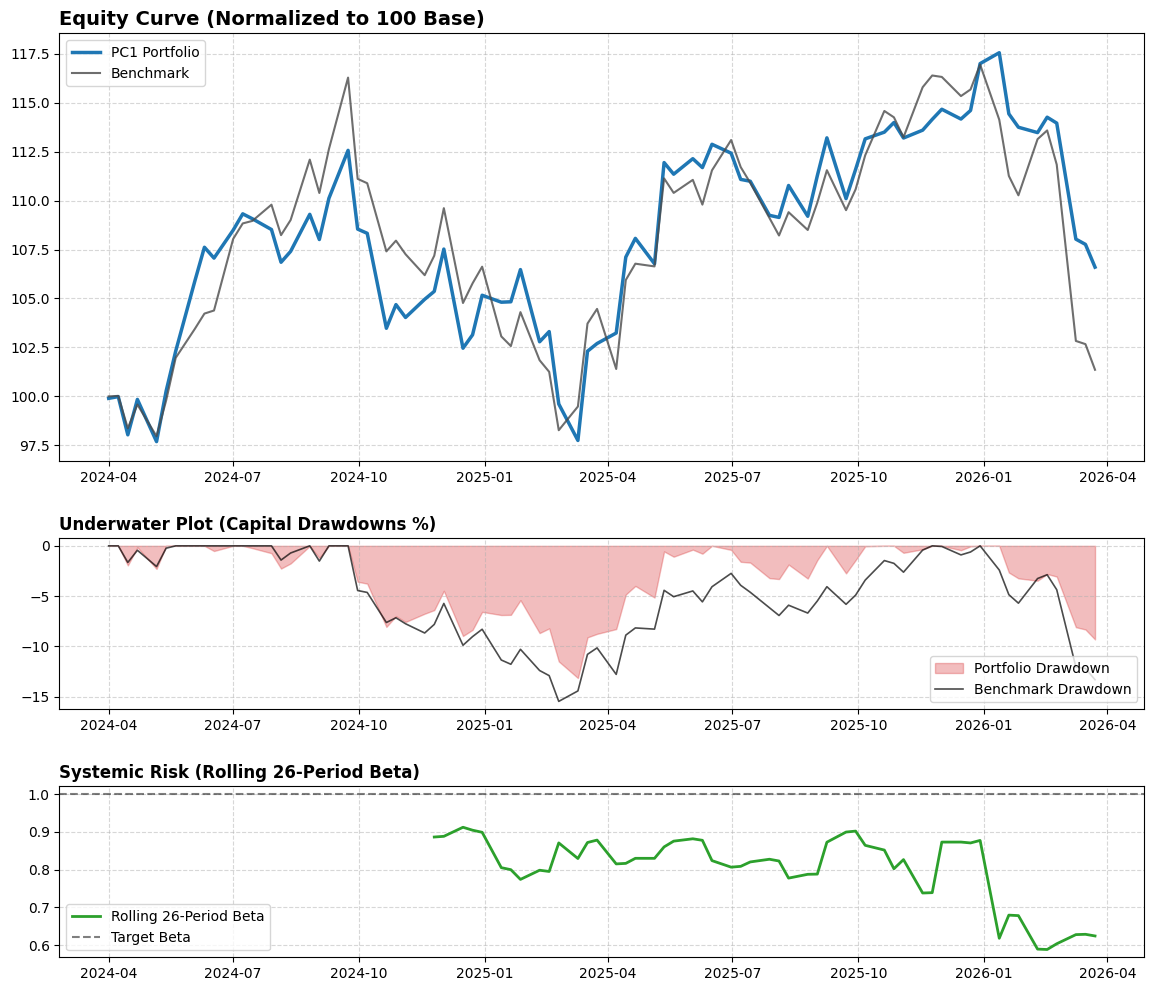

In [658]:

evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=104, hold=4, retrain_every=4)


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-03-23


,Portfolio,Benchmark
Return (CAGR),4.75%,0.90%
Volatility,13.74%,15.12%
Sharpe Ratio,-0.09,-0.34
Sortino Ratio,-0.13,-0.45
Max Drawdown,-12.71%,-15.49%
Calmar Ratio,0.37,0.06
Beta,0.76,1.00
Jensen's Alpha,2.63%,0.00%


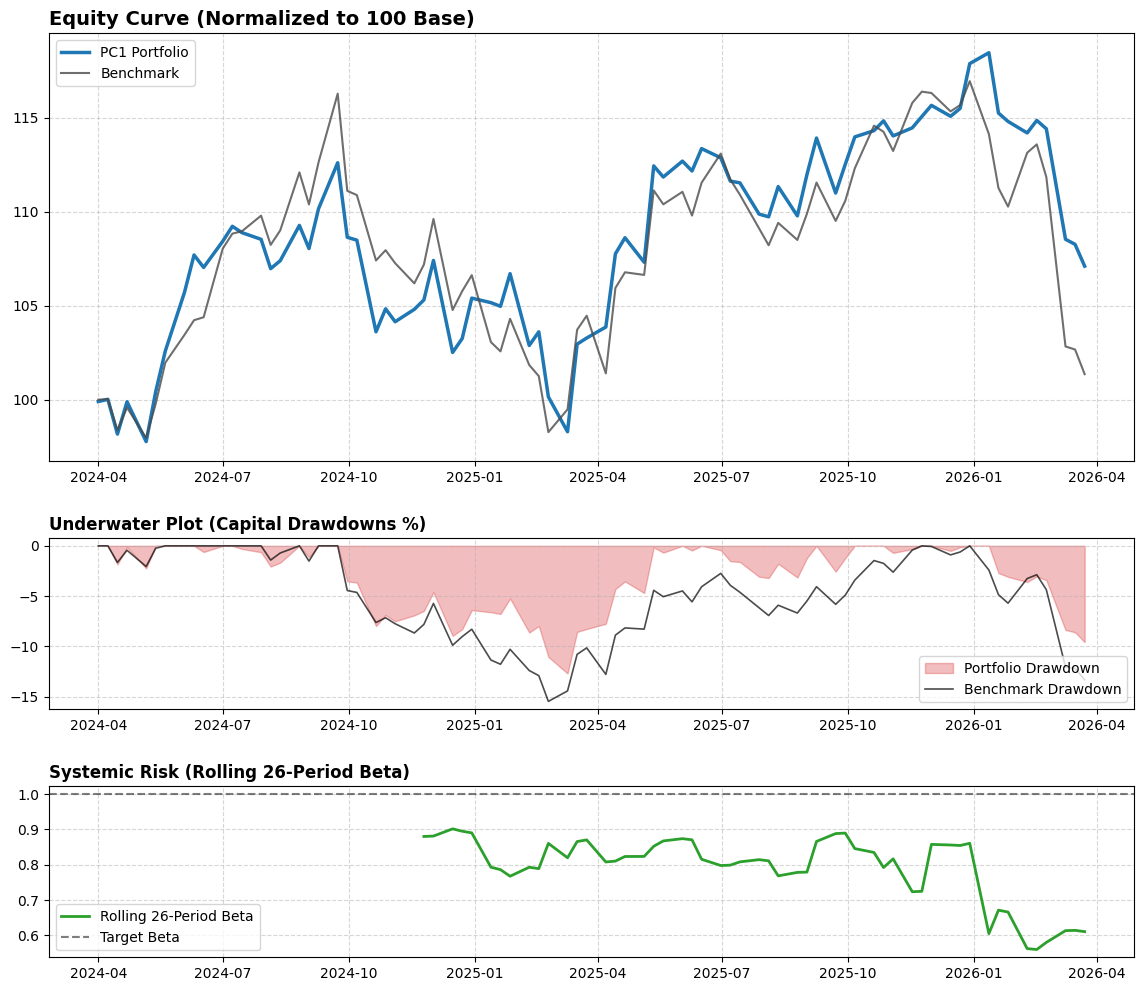

In [659]:
evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=52, hold=4, retrain_every=4, tc=0.001)


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-03-23


,Portfolio,Benchmark
Return (CAGR),3.86%,0.90%
Volatility,13.91%,15.12%
Sharpe Ratio,-0.15,-0.34
Sortino Ratio,-0.21,-0.45
Max Drawdown,-13.54%,-15.49%
Calmar Ratio,0.29,0.06
Beta,0.78,1.00
Jensen's Alpha,1.82%,0.00%


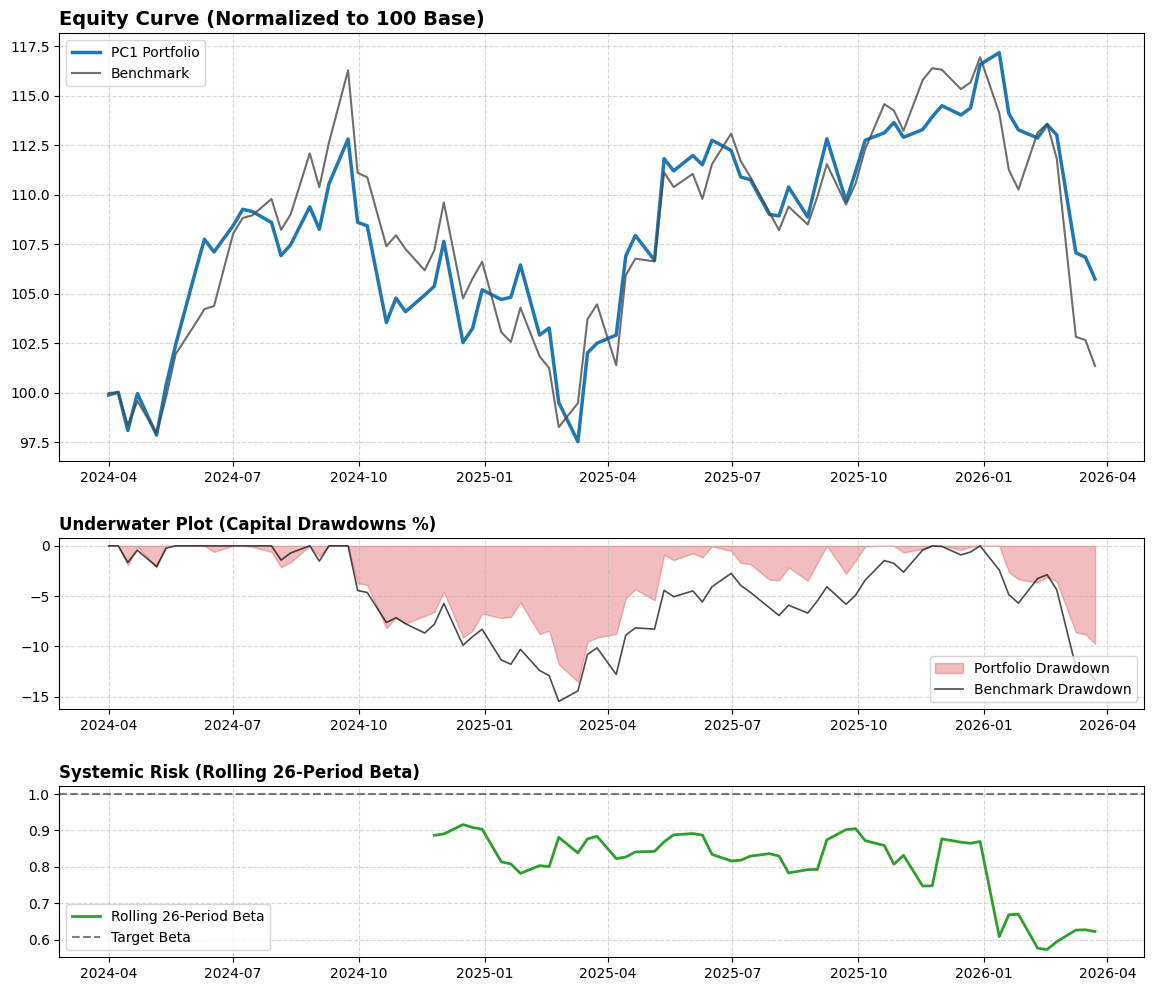

In [660]:
evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=208, hold=4, retrain_every=4, tc=0.001)


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-01-26


,Portfolio,Benchmark
Return (CAGR),6.05%,5.95%
Volatility,13.52%,12.98%
Sharpe Ratio,0.00,-0.00
Sortino Ratio,0.01,-0.01
Max Drawdown,-17.86%,-15.49%
Calmar Ratio,0.34,0.38
Beta,0.96,1.00
Jensen's Alpha,0.10%,0.00%


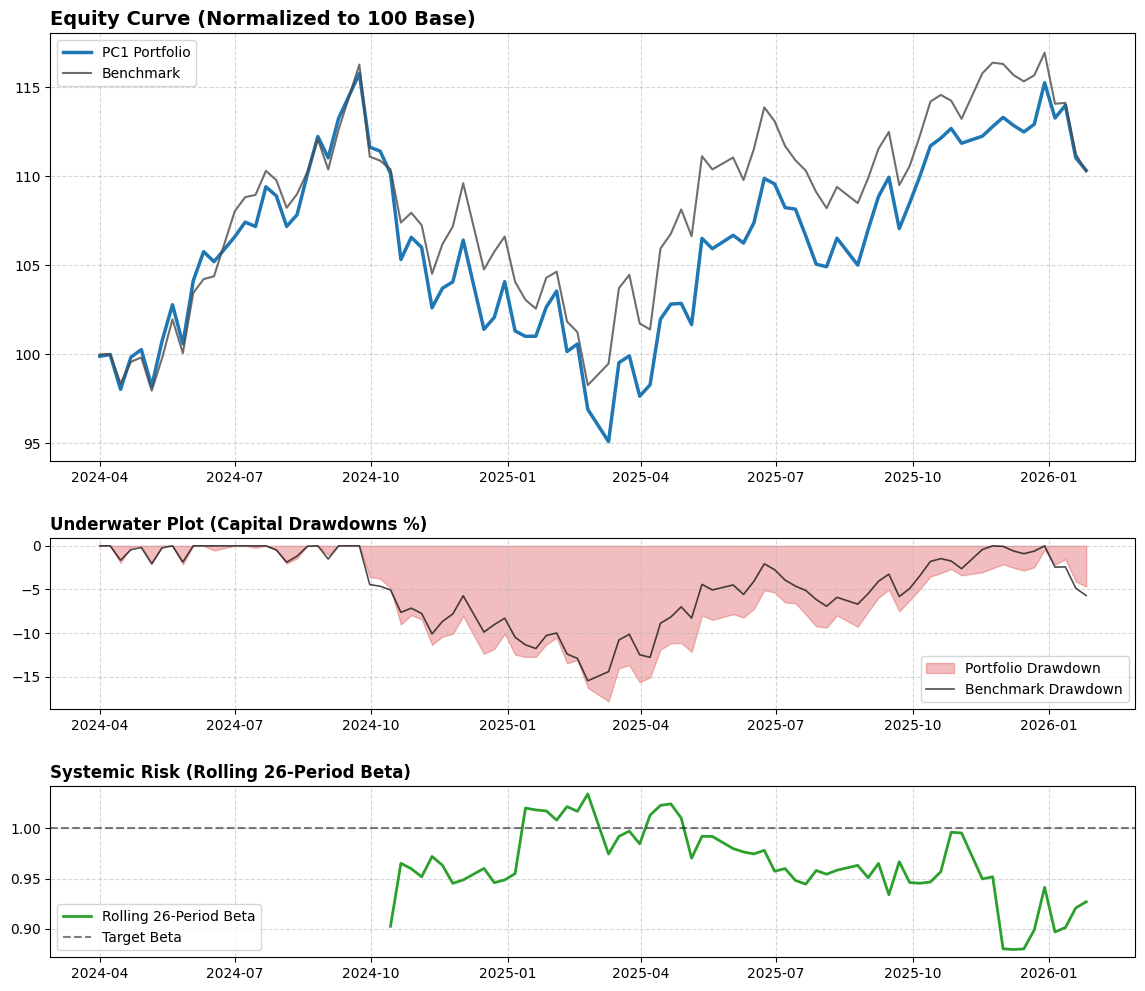

In [661]:
evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=104, hold=12, retrain_every=12, tc=0.001)


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-03-23


,Portfolio,Benchmark
Return (CAGR),3.07%,0.77%
Volatility,13.48%,13.27%
Sharpe Ratio,-0.22,-0.39
Sortino Ratio,-0.30,-0.54
Max Drawdown,-13.07%,-15.49%
Calmar Ratio,0.23,0.05
Beta,0.90,1.00
Jensen's Alpha,1.79%,0.00%


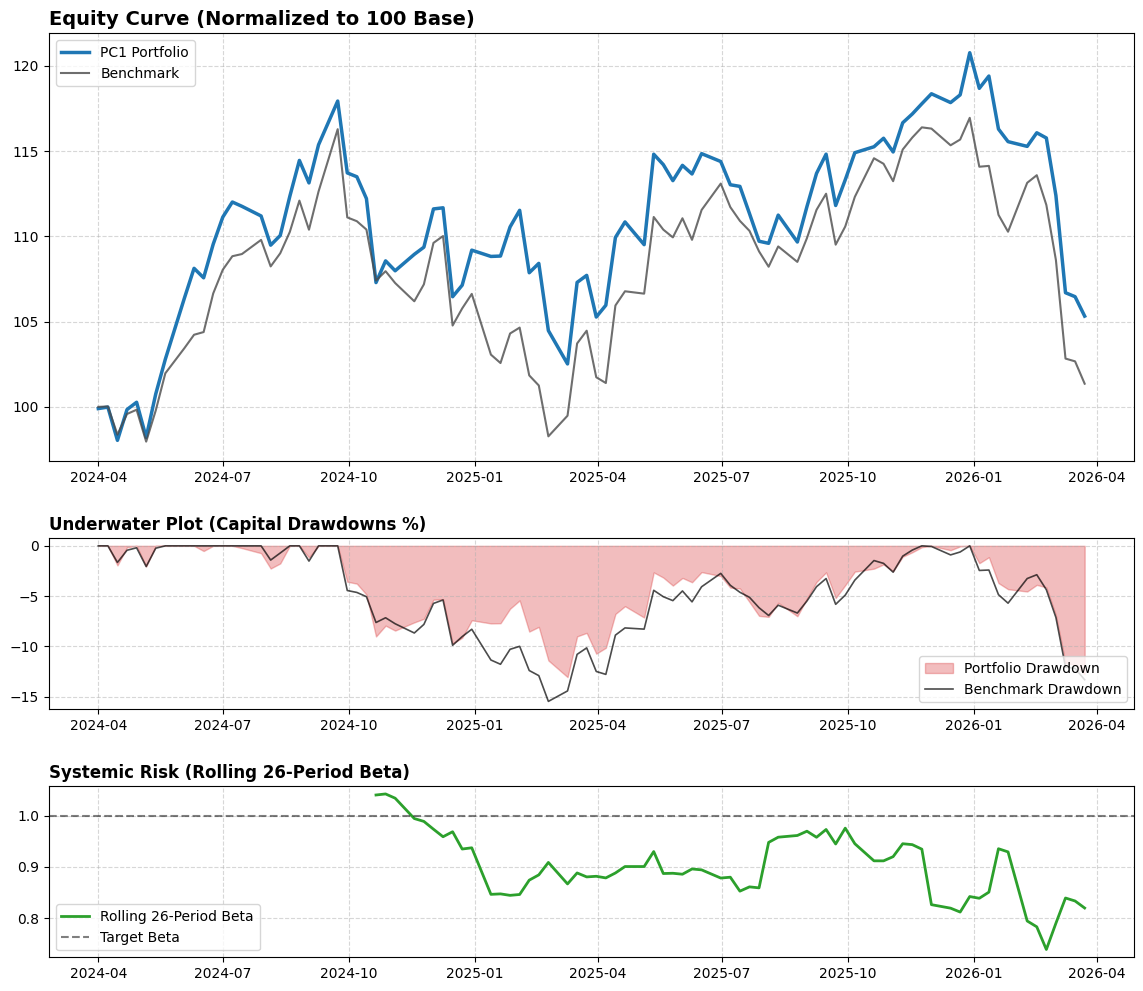

In [662]:
evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=104, hold=8, retrain_every=8, tc=0.001)


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-04-06


,Portfolio,Benchmark
Return (CAGR),-2.56%,6.69%
Volatility,14.77%,19.69%
Sharpe Ratio,-0.58,0.04
Sortino Ratio,-0.78,0.05
Max Drawdown,-18.01%,-15.49%
Calmar Ratio,-0.14,0.43
Beta,0.53,1.00
Jensen's Alpha,-8.92%,0.00%


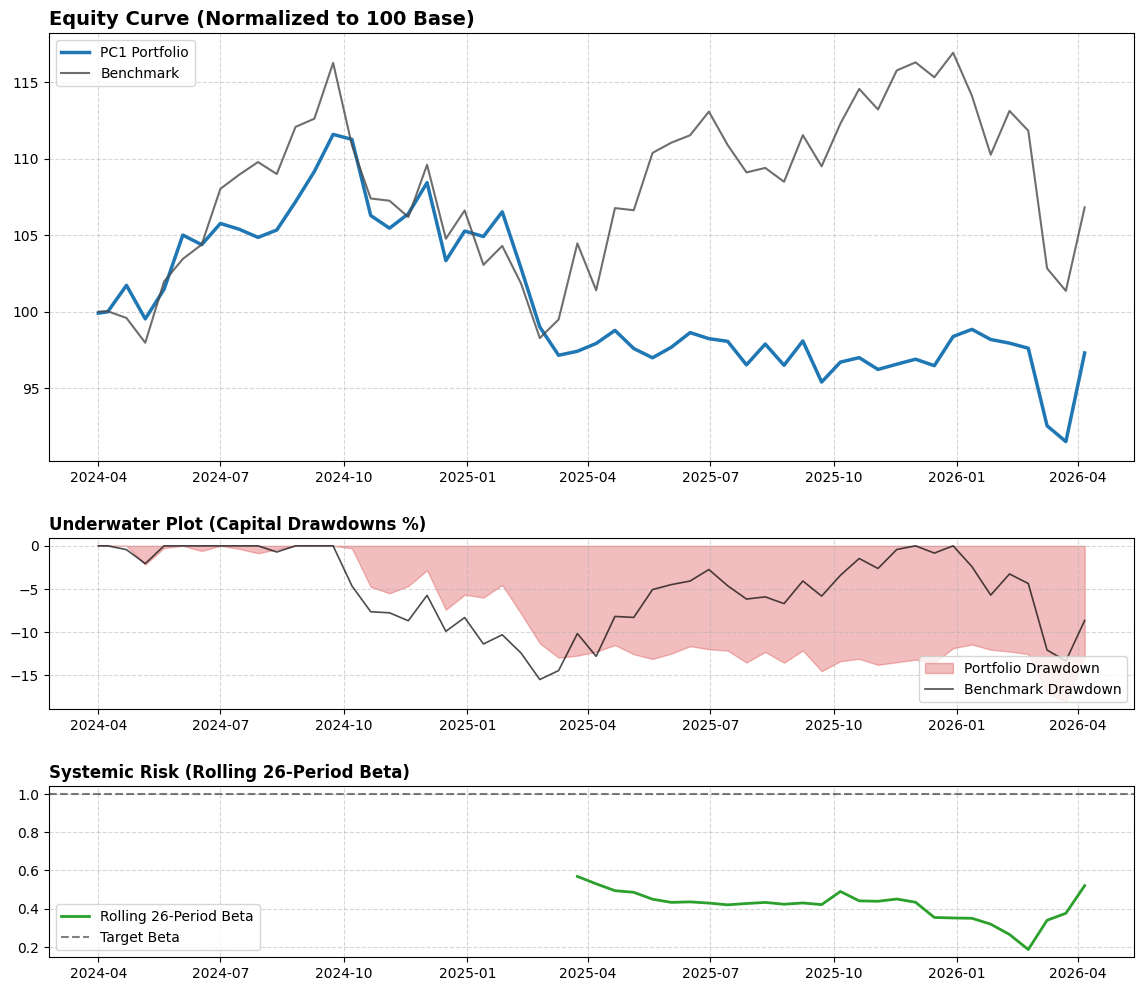

In [663]:
evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=104, hold=2, retrain_every=2, tc=0.001)


 ROLLING STRATEGY REPORT: PC1 [Long-Only]
 Period: 2024-04-01 to 2026-01-26


,Portfolio,Benchmark
Return (CAGR),5.72%,5.95%
Volatility,13.45%,12.98%
Sharpe Ratio,-0.02,-0.00
Sortino Ratio,-0.03,-0.01
Max Drawdown,-18.28%,-15.49%
Calmar Ratio,0.31,0.38
Beta,0.96,1.00
Jensen's Alpha,-0.23%,0.00%


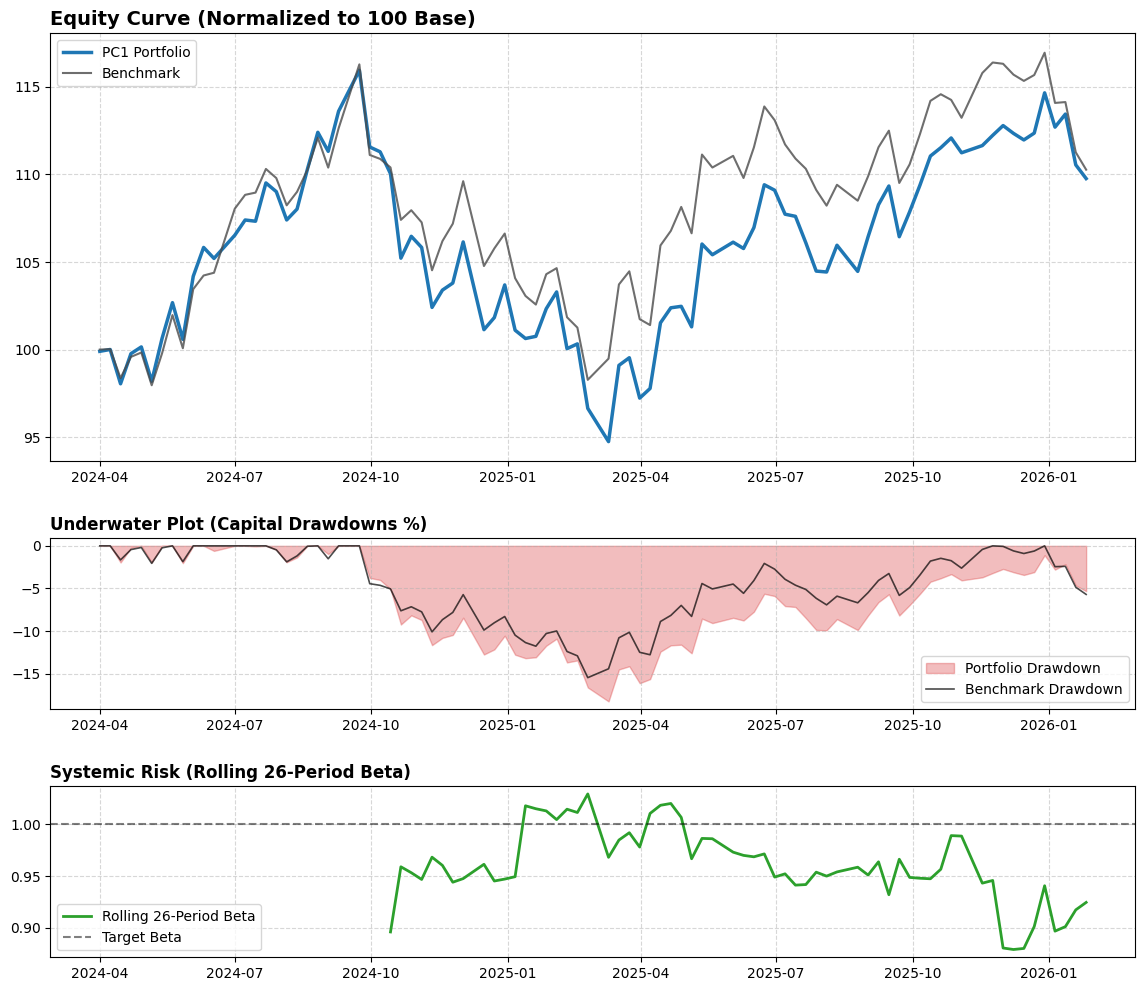

In [664]:
evaluate_pc_strategy_roll(pc_index=0,price_data=pd.concat([close_train_prices, close_test_prices]),benchmark_data=benchmark, strategy='auto', initial_capital=100000, rf_rate=0.06, periods_per_yr=52, lookback=156, hold=12, retrain_every=12, tc=0.001)